## Library

In [1]:
import xgboost as xgb
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
import pathlib
from glob import glob
import warnings
warnings.filterwarnings("ignore")

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, f1_score, classification_report, ConfusionMatrixDisplay
from sklearn.model_selection import StratifiedKFold
## XGBoost Baseline - Config
RANDOM_STATE = 42
OUTPUT_PATH = pathlib.Path("../all_dataset/clean_dataset/dataset-5-kelas-68d")

In [2]:
TEST_SIZE = 0.2

def load_metrics(dataset_path: pathlib.Path) -> pd.DataFrame:
    csv_files = glob(str(dataset_path / "**" / "metrics.csv"), recursive=True)
    if not csv_files:
        raise FileNotFoundError(f"Tidak ada metrics.csv ditemukan di: {dataset_path}")

    df = pd.concat((pd.read_csv(f) for f in csv_files), ignore_index=True)
    return df

full_df = load_metrics(OUTPUT_PATH)

train_df, test_df = train_test_split(
    full_df,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=full_df["class_name"],
)

print(f"Train rows: {len(train_df):,} | Test rows: {len(test_df):,}")
print(f"Train classes: {sorted(train_df['class_name'].dropna().unique().tolist())}")
print(f"Test classes : {sorted(test_df['class_name'].dropna().unique().tolist())}")

train_df.head()

Train rows: 196 | Test rows: 50
Train classes: ['Heart', 'Oblong', 'Oval', 'Round', 'Square']
Test classes : ['Heart', 'Oblong', 'Oval', 'Round', 'Square']


,class_name,image_file,relative_path,face_height,face_width,forehead_height,jaw_width,chin_width,chin_angle_degree,forehead_width,skeleton_angle_left,skeleton_angle_right,jidat_angle_downward
128,Oval,news_1436421554_514612_m_1.jpg,Oval/news_1436421554_514612_m_1.jpg,0.815831,0.645319,0.315574,0.504914,0.282906,100.016281,0.618852,-10.980650,15.124007,177.954590
184,Round,image_28.jpg,Round/image_28.jpg,0.955048,0.694156,0.466049,0.545018,0.305720,111.595467,0.623843,-15.410813,11.237898,143.477631
75,Oblong,oblong (556).jpg,Oblong/oblong (556).jpg,0.920396,0.626766,0.362550,0.513929,0.300948,112.947166,0.561753,-5.648247,8.504579,175.880096
139,Oval,oblong (9).jpg,Oval/oblong (9).jpg,0.932815,0.691801,0.296443,0.581041,0.355731,112.072464,0.581028,-1.548158,5.609274,180.000000
67,Oblong,oblong (891).jpg,Oblong/oblong (891).jpg,0.934553,0.691148,0.356364,0.545467,0.330909,103.931778,0.621818,-6.842773,13.366930,180.000000


In [3]:
id_columns = ["class_name", "image_file", "relative_path", "section"]
target_col = "class_name"

candidate_features = [col for col in train_df.columns if col not in id_columns and col in test_df.columns]

X_train_raw = train_df[candidate_features].copy()
X_test_raw = test_df[candidate_features].copy()
y_train_raw = train_df[target_col].astype(str).copy()
y_test_raw = test_df[target_col].astype(str).copy()

# Force numeric where possible
for col in candidate_features:
    X_train_raw[col] = pd.to_numeric(X_train_raw[col], errors="coerce")
    X_test_raw[col] = pd.to_numeric(X_test_raw[col], errors="coerce")

valid_feature_columns = [
    col for col in candidate_features
    if not (X_train_raw[col].isna().all() and X_test_raw[col].isna().all())
]

X_train_raw = X_train_raw[valid_feature_columns]
X_test_raw = X_test_raw[valid_feature_columns]

# Selective normalization: angle -> abs, degree -> /360
angle_columns = [col for col in valid_feature_columns if "angle" in col.lower()]
degree_columns = [col for col in valid_feature_columns if "degree" in col.lower()]

for col in angle_columns:
    X_train_raw[col] = X_train_raw[col].abs()
    X_test_raw[col] = X_test_raw[col].abs()

for col in degree_columns:
    X_train_raw[col] = X_train_raw[col] / 360
    X_test_raw[col] = X_test_raw[col] / 360

pass_columns = [col for col in valid_feature_columns if col not in set(angle_columns + degree_columns)]

print("Total fitur:", len(valid_feature_columns))
print("Kolom angle (abs):", angle_columns)
print("Kolom degree (bagi 360):", degree_columns)
print("Kolom fitur lain (tanpa scaling):", pass_columns)

if not valid_feature_columns:
    raise ValueError("Tidak ada fitur valid setelah preprocessing.")

Total fitur: 10
Kolom angle (abs): ['chin_angle_degree', 'skeleton_angle_left', 'skeleton_angle_right', 'jidat_angle_downward']
Kolom degree (bagi 360): ['chin_angle_degree']
Kolom fitur lain (tanpa scaling): ['face_height', 'face_width', 'forehead_height', 'jaw_width', 'chin_width', 'forehead_width']


In [4]:
transformers = [
    (
        "impute_all_numeric",
        Pipeline(steps=[("imputer", SimpleImputer(strategy="median"))]),
        valid_feature_columns,
    )
]

preprocessor = ColumnTransformer(
    transformers=transformers,
    remainder="drop",
    verbose_feature_names_out=False,
    sparse_threshold=0,
 )

label_encoder = LabelEncoder()
y_train = label_encoder.fit_transform(y_train_raw)

unseen_labels = sorted(set(y_test_raw.unique()) - set(label_encoder.classes_))
if unseen_labels:
    raise ValueError(f"Ada label testing yang tidak ada di training: {unseen_labels}")

y_test = label_encoder.transform(y_test_raw)

print("Label mapping:", dict(enumerate(label_encoder.classes_)))

Label mapping: {0: 'Heart', 1: 'Oblong', 2: 'Oval', 3: 'Round', 4: 'Square'}


In [5]:
xgb_baseline = xgb.XGBClassifier(
    objective="multi:softprob",
    eval_metric="mlogloss",
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=RANDOM_STATE,
    use_label_encoder=False,
    n_jobs=-1,
 )

pipeline_xgb = Pipeline(steps=[("prep", preprocessor), ("model", xgb_baseline)])

In [6]:
print("Training XGBoost baseline...")
pipeline_xgb.fit(X_train_raw, y_train)

Training XGBoost baseline...


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('prep', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('impute_all_numeric', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains 

Test Accuracy: 0.5800 | Test F1 (weighted): 0.5850

Classification report:
              precision    recall  f1-score   support

       Heart     0.7778    0.7000    0.7368        10
      Oblong     0.5000    0.5000    0.5000        10
        Oval     0.4167    0.5000    0.4545        10
       Round     0.8333    0.5000    0.6250        10
      Square     0.5385    0.7000    0.6087        10

    accuracy                         0.5800        50
   macro avg     0.6132    0.5800    0.5850        50
weighted avg     0.6132    0.5800    0.5850        50



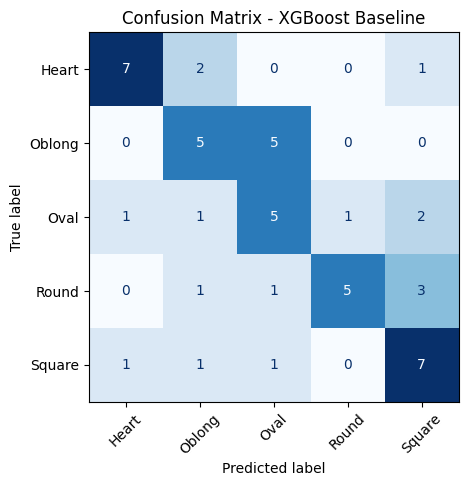

In [7]:
y_pred = pipeline_xgb.predict(X_test_raw)
acc = accuracy_score(y_test, y_pred)
f1w = f1_score(y_test, y_pred, average="weighted")
print(f"Test Accuracy: {acc:.4f} | Test F1 (weighted): {f1w:.4f}")

print("\nClassification report:")
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_, digits=4))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=label_encoder.classes_,
    cmap="Blues",
    xticks_rotation=45,
    colorbar=False,
    values_format="d",
 )
plt.title("Confusion Matrix - XGBoost Baseline")
plt.show()

In [11]:
# 8) Save trained pipeline and label encoder to models folder
models_dir = pathlib.Path("../models").resolve()
models_dir.mkdir(parents=True, exist_ok=True)
model_path = models_dir / "xgb_baseline_pipeline.joblib"
label_path = models_dir / "label_encoder.joblib"
joblib.dump(pipeline_xgb, model_path)
joblib.dump(label_encoder, label_path)

print(f"Saved model pipeline to: {model_path}")
print(f"Saved label encoder to: {label_path}")

Saved model pipeline to: D:\Thoriq\Work\MadeByHumans\Research Face Shape\models\xgb_baseline_pipeline.joblib
Saved label encoder to: D:\Thoriq\Work\MadeByHumans\Research Face Shape\models\label_encoder.joblib


In [12]:
# 9) Load saved model and run inference demo on sample test rows
print("Loading saved model for inference demo...")
loaded_pipeline = joblib.load(model_path)
loaded_le = joblib.load(label_path)

sample_idx = list(range(min(10, len(X_test_raw))))
X_sample = X_test_raw.iloc[sample_idx]
y_sample = y_test[sample_idx]
pred_sample = loaded_pipeline.predict(X_sample)
pred_labels = loaded_le.inverse_transform(pred_sample)
true_labels = loaded_le.inverse_transform(y_sample)

demo_df = X_sample.copy().reset_index(drop=True)
demo_df["true_label"] = true_labels
demo_df["pred_label"] = pred_labels
display(demo_df.head(10))

Loading saved model for inference demo...


,face_height,face_width,forehead_height,jaw_width,chin_width,chin_angle_degree,forehead_width,skeleton_angle_left,skeleton_angle_right,jidat_angle_downward,true_label,pred_label
0,0.848460,0.649766,0.324873,0.528016,0.299492,0.313627,0.604061,5.710593,9.188836,197.758301,Heart,Heart
1,0.854594,0.609091,0.331818,0.495475,0.277273,0.300286,0.600000,10.437474,10.573523,183.912903,Heart,Heart
2,0.863597,0.625445,0.367925,0.502912,0.284205,0.292698,0.514151,9.668669,11.309932,114.795166,Heart,Oval
3,0.830054,0.630716,0.372943,0.495514,0.279761,0.286648,0.610603,13.940590,17.130300,172.883041,Heart,Heart
4,0.854671,0.605098,0.343023,0.500135,0.273256,0.291696,0.406977,9.130177,3.179830,135.784821,Heart,Heart
5,0.849949,0.608708,0.339921,0.506068,0.280883,0.309524,0.537549,9.782407,7.460566,178.152374,Heart,Oval
6,0.904812,0.641602,0.377778,0.516071,0.300151,0.294381,0.588889,5.572197,13.150948,184.555054,Heart,Oval
7,0.983814,0.728902,0.404732,0.572512,0.306488,0.292864,0.515567,0.716160,20.136301,140.882431,Heart,Heart
8,0.916944,0.635313,0.402280,0.513122,0.291604,0.303156,0.117264,0.285051,10.936849,132.009644,Heart,Oval
9,0.890412,0.596903,0.360784,0.475546,0.263213,0.273992,0.505882,5.906141,8.637131,176.531769,Heart,Oblong


In [15]:
# 10) (last) Save sample predictions CSV to analysis folder
analysis_dir = pathlib.Path(os.curdir) / "_analysis"
analysis_dir.mkdir(parents=True, exist_ok=True)
sample_pred_csv = analysis_dir / "xgb_baseline_sample_predictions.csv"
pred_df = demo_df[["true_label", "pred_label"] + list(X_sample.columns)]
pred_df.to_csv(sample_pred_csv, index=False)
print(f"Saved sample predictions to: {sample_pred_csv}")

Saved sample predictions to: _analysis\xgb_baseline_sample_predictions.csv
